# Freelance Project Recommendation Engine

This notebook implements a weighted scoring recommendation engine combining:
1. **Category Similarity (50%)**
2. **Experience Compatibility (30%)**
3. **Budget Fit (20%)**

It ranks projects from the standard dataset and recommends the most relevant opportunities to freelancers.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
file_path = r'C:\Users\dali\Desktop\Freelance Platform Projects.csv'
df = pd.read_csv(file_path)

print(f"Loaded {len(df)} projects.")
df.head(2)

Loaded 12222 projects.


,Title,Category Name,Experience,Sub Category Name,Currency,Budget,Location,Freelancer Preferred From,Type,Date Posted,Description,Duration,Client Registration Date,Client City,Client Country,Client Currency,Client Job Title
0,Banner images for web desgin websites,Design,Entry ($),Graphic Design,EUR,60.0,remote,ALL,fixed_price,2023-04-29 18:06:39,We are looking to improve the banner images on...,NaN,2010-11-03,Dublin,Ireland,EUR,PPC Management
1,Make my picture a solid silhouette,"Video, Photo & Image",Entry ($),Image Editing,GBP,20.0,remote,ALL,fixed_price,2023-04-29 17:40:28,Hello \n\nI need a quick designer to make 4 pi...,NaN,2017-02-21,London,United Kingdom,GBP,Office manager


## Scoring Implementation

We define numerical mappings for Experience levels to allow for mathematical comparison.

In [7]:
experience_map = {
    'Entry ($)': 1,
    'Intermediate ($$)': 2,
    'Expert ($$$)': 3
}

def calculate_recommendations(freelancer_profile, projects_df):
    results = projects_df.copy()
    
    results['category_score'] = (results['Category Name'] == freelancer_profile['category']).astype(float) * 0.5
    
    freelancer_exp_val = experience_map.get(freelancer_profile['experience_level'], 1)
    
    def get_exp_score(row_exp):
        proj_exp_val = experience_map.get(row_exp, 1)
        diff = abs(freelancer_exp_val - proj_exp_val)
        if diff == 0: return 1.0
        if diff == 1: return 0.7
        return 0.3
    
    results['experience_score'] = results['Experience'].apply(get_exp_score) * 0.3
    
    target_budget = freelancer_profile['min_budget']
    results['budget_score'] = results['Budget'].apply(lambda x: min(1.0, x / target_budget) if target_budget > 0 else 1.0) * 0.2
    results['total_score'] = results['category_score'] + results['experience_score'] + results['budget_score']
    
    return results.sort_values(by='total_score', ascending=False)

## Example User Profile & Results

Let's simulate a freelancer profile looking for 'Design' projects.

In [8]:
test_freelancer = {
    'category': 'Design',
    'experience_level': 'Intermediate ($$)',
    'min_budget': 50.0
}

recommendations = calculate_recommendations(test_freelancer, df)
top_recs = recommendations.head(10)

print(f"Top Recommendations for Category: {test_freelancer['category']}")
top_recs[['Title', 'Category Name', 'Experience', 'Budget', 'total_score']]

Top Recommendations for Category: Design


,Title,Category Name,Experience,Budget,total_score
12218,Shopify - Filtering Work (Product Selection/No...,Design,Intermediate ($$),65.0,1.0
12207,Logo for career coaching company,Design,Intermediate ($$),90.0,1.0
2654,estimator project,Design,Intermediate ($$),150.0,1.0
9267,School Games Poster,Design,Intermediate ($$),65.0,1.0
9286,Etsy print on demand design and etsy listing c...,Design,Intermediate ($$),99.0,1.0
11443,I need a website design with e commerce functi...,Design,Intermediate ($$),75.0,1.0
11408,Sewing help for production of baby comforters ...,Design,Intermediate ($$),80.0,1.0
2708,i need a logo for print on demand,Design,Intermediate ($$),65.0,1.0
2552,I need a logo and an animation,Design,Intermediate ($$),120.0,1.0
11442,CGI images 3D visualisation,Design,Intermediate ($$),120.0,1.0


## Visualization

A visual representation of the recommended projects and their match percentages.

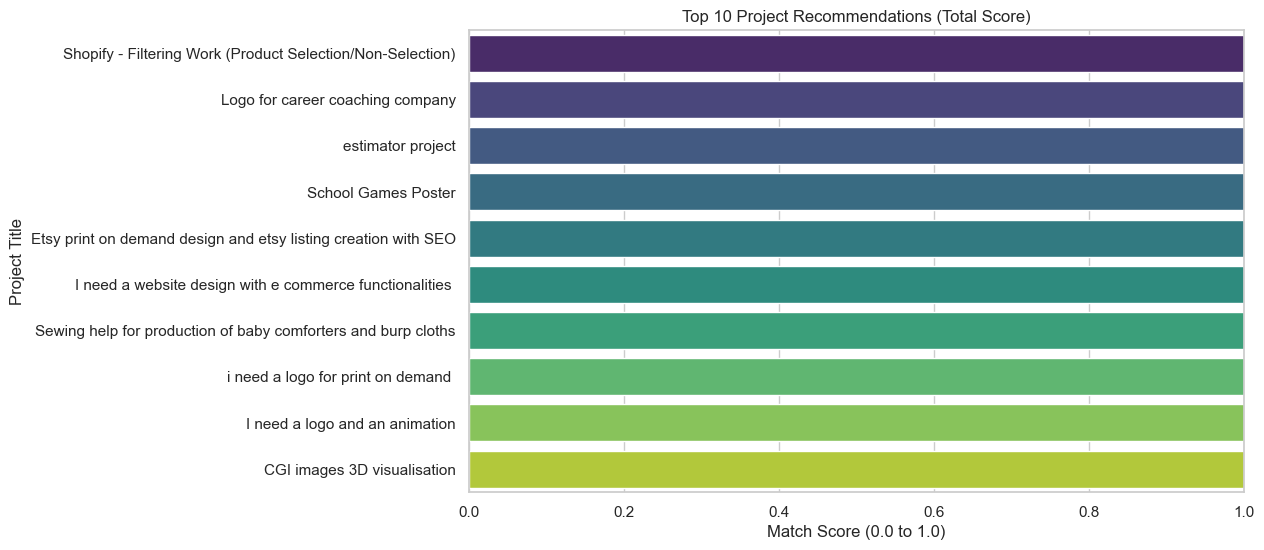

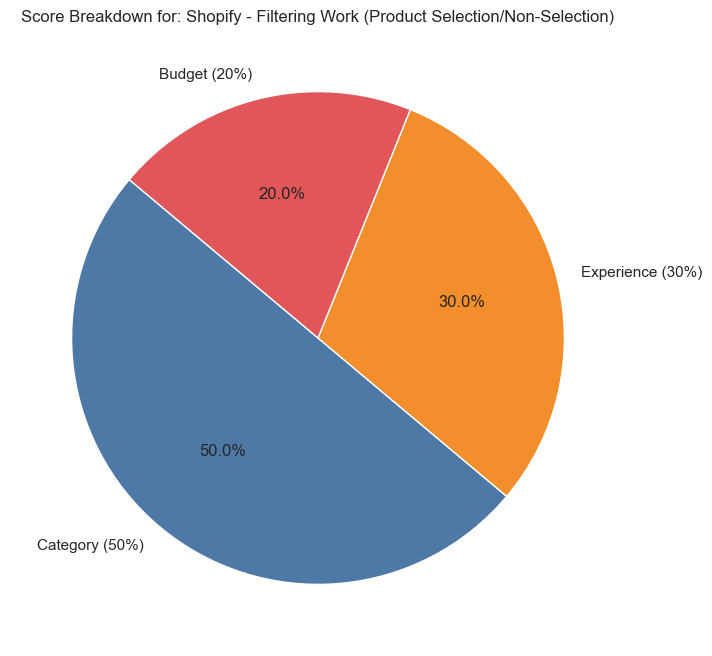

In [9]:
# Visualizing the top 10 projects
plt.figure(figsize=(10, 6))
sns.barplot(data=top_recs, x='total_score', y='Title', hue='Title', palette='viridis', legend=False)
plt.title(f"Top 10 Project Recommendations (Total Score)")
plt.xlabel("Match Score (0.0 to 1.0)")
plt.ylabel("Project Title")
plt.xlim(0, 1.0)
plt.show()

# Breakdown of the top project's score
best_match = top_recs.iloc[0]
scores = [best_match['category_score'], best_match['experience_score'], best_match['budget_score']]
labels = ['Category (50%)', 'Experience (30%)', 'Budget (20%)']

plt.figure(figsize=(8, 8))
plt.pie(scores, labels=labels, autopct='%1.1f%%', colors=['#4e79a7', '#f28e2b', '#e15759'], startangle=140)
plt.title(f"Score Breakdown for: {best_match['Title']}")
plt.show()